# DELTA1 Quant Research: Breadth TSMOM

**An explainable, cost-aware trend-following CTA across 43 global futures markets, with a
pre-registered evaluation and a walk-forward training experiment.**

Version 2 of this research keeps the version-1 forecast — the sign of the 12-month price
move — completely unchanged and makes one intervention: it widens the universe from 22 to
43 USD-denominated futures under a written, numeric inclusion rule. On the primary
evidence window (1990–2004) the net Sharpe ratio rises from 1.27 to 1.57, and on the
2005–2014 evaluation window from 0.70 to 0.89 with CAGR rising from 7.0% to 9.4% — at a
10% volatility target, with two-sided trading costs charged throughout, and with the gain
surviving every stress scenario tested below. A five-model walk-forward selection
experiment ("training") is run alongside and honestly reported: it does **not** beat the
simple pre-specified forecast, consistent with the forecast-combination literature.

## 1. Research question

Version 1 asked whether a literature-backed 12-month time-series-momentum signal could be
improved with transparent volatility and execution controls; the answer was "modestly."
Version 2 asks the next question in order of prior plausibility:

> **Does widening the traded universe — the one improvement the fundamental law of active
> management predicts most reliably — raise CAGR and Sharpe out of sample, and does
> data-driven model selection (walk-forward "training") add anything beyond it?**

Three design principles carried over from v1: the alpha model stays simple and
falsifiable; every value at date *t* depends only on data at or before *t*; and every
reported number is net of explicit spread-plus-commission costs.

### Pre-registration and honest windows

The supplied data end on 2014-12-31 and v1 already reported results on 2005–2014, so no
untouched holdout exists. Every v2 design choice was therefore frozen in
[`PREREGISTRATION.md`](PREREGISTRATION.md) — with its justification recorded as
*literature* or *pre-2005 evidence* — before the single official evaluation run, and:

- **1990–2004** is the *primary evidence window*: the improvement must show there first;
- **2005–2014** is the *evaluation window (second use)* — deliberately never called
  "out-of-sample" in this notebook;
- a **claim rule** was fixed in advance: the improvement is claimed only if the 90%
  paired-bootstrap interval of the Sharpe difference excludes zero in 1990–2004 **and**
  the 2005–2014 point estimate is positive with ≥ 6 of 10 winning calendar years.

### Research basis

- Moskowitz, Ooi & Pedersen, *Time Series Momentum*, JFE 2012 — 12-month sign momentum across 58 futures.
- Hurst, Ooi & Pedersen, *A Century of Evidence on Trend-Following Investing*, JPM 2017 — 67 markets.
- Baz, Granger, Harvey, Le Roux & Rattray, *Dissecting Investment Strategies in the Cross Section and Time Series*, 2015 — doubly-normalized continuous trend signals.
- Grinold's fundamental law — IR grows with the square root of independent bets (breadth).
- Timmermann, *Forecast Combination*, 2006; DeMiguel, Garlappi & Uppal, RFS 2009 — combination/simple rules beat selection.
- Bailey, Borwein, López de Prado & Zhu, *The Probability of Backtest Overfitting*, JCF 2017 — CSCV PBO, PSR/DSR.

## 2. Methodology

### 2.1 Universe: 43 markets from a written rule

Every USD-denominated back-adjusted continuous contract in the supplied catalogue (56) is
a member unless excluded for one of three named reasons — duplicate exposure (WBS, LSU,
LRC, MWE, GD, DX), broken mechanics (VX is not delta-one; ZQ's price volatility collapses
at the zero lower bound, breaking 1/σ sizing), or a numeric liquidity rule of roughly
$100M median daily dollar volume (LBS, ZR, DC, OJ, ZO). That leaves six classes: 7 equity
indices, 4 government bonds, 8 FX, 6 energy, 5 metals, 13 agriculture & livestock.

Two point-in-time safeguards make the wider universe implementable rather than
theoretical: a market is tradeable on day *t* only if its trailing 60-session median
reported volume exceeds 1,000 contracts (this keeps 6N out until mid-2007 — its 2005–06
marks carry zero reported volume), and exchange closures up to 10 business days carry the
last price at zero P&L, so recurring holidays (Taiwan's Lunar New Year closures in HTW)
hold positions instead of forcing spurious round trips.

### 2.2 Forecast: unchanged from v1

```text
direction[i, t] = sign(close[i, t] − close[i, t − 252])
```

### 2.3 Risk and execution: unchanged from v1, shared by every variant

1. contract risk from lagged EWM (span 60) volatility of daily price changes;
2. equal ex-ante risk across the six classes, equal risk within each class;
3. exposure tapered when 20-day volatility rises far above 120-day volatility;
4. 10% annualized portfolio volatility target, leverage clipped to [0.25, 2];
5. 25% no-trade region on month-end position changes;
6. month-end targets activate the next business day;
7. P&L from price change × point value; half-tick spread + $2.50 per contract per side.

Price changes — not percentage returns — are used throughout because the back-adjusted
series can approach or cross zero.

### 2.4 The training experiment: rolling walk-forward model selection

Five forecast models were pre-declared: the v1 sign(12m); a sign blend over 3/6/12
months; and three continuous "trend-strength" variants (Baz et al. 2015 double
normalization: the h-day move over σ·√h, re-scaled by its own trailing one-year standard
deviation, clipped at ±2σ). At each December year-end from 1990, the model with the best
trailing 60-month net Sharpe is chosen and run for the following calendar year; the
composite target stream is then re-run through the full shared risk/execution/cost
pipeline in one forward pass, so switch trades are charged and nothing uses future data.
This is genuine rolling out-of-sample training — every post-1991 walk-forward return
follows a model chosen using only prior data — and it lets the data argue *against*
complexity if complexity does not pay.

In [1]:
%matplotlib inline
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))

from delta1_cta import BacktestConfig
from enhanced_strategy import (
    EXPANDED_ASSET_CLASSES,
    HOLDOUT_WINDOW,
    PRIMARY_WINDOW,
    enhanced_invariants,
    run_enhanced_pipeline,
    save_enhanced_outputs,
)

DATA_DIR = Path(os.environ.get("DELTA1_DATA_DIR", str(ROOT / "data" / "Delta1")))
OUTPUT_DIR = ROOT / "outputs"
assert (DATA_DIR / "CATALOGUE_Delta1_Futures.csv").exists(), "Set DELTA1_DATA_DIR."
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

# Chart tokens: categorical palette in fixed order, text and grid stay recessive.
C_HEADLINE, C_BASELINE, C_WALKFWD, C_ENSEMBLE = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
INK, INK_2, GRID = "#0b0b0b", "#52514e", "#e5e5e2"
plt.rcParams.update({
    "axes.edgecolor": GRID, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.axisbelow": True, "text.color": INK,
    "axes.labelcolor": INK_2, "xtick.color": INK_2, "ytick.color": INK_2,
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "font.size": 10.5, "axes.titlesize": 12,
})

base_config = BacktestConfig(data_dir=DATA_DIR, output_dir=OUTPUT_DIR)
output = run_enhanced_pipeline(base_config)          # ~3 minutes: all variants + stress
invariants = enhanced_invariants(output, base_config)
save_enhanced_outputs(output, invariants, base_config)
assert bool(invariants.all()), invariants[~invariants]
invariants.to_frame()

,Pass
headline_finite_net_returns,True
headline_non_negative_costs,True
headline_forecast_bounded,True
headline_positions_change_only_at_month_boundary,True
walk_forward_finite_net_returns,True
walk_forward_non_negative_costs,True
walk_forward_forecast_bounded,True
walk_forward_positions_change_only_at_month_boundary,True
holdout_exceeds_five_years,True
selection_uses_only_prior_years,True


## 3. Findings

### 3.1 Headline comparison

Both windows, all strategies, everything net of costs at a 10% volatility target. The
walk-forward and ensemble rows are the training experiment; the long-only row shows what
trend direction adds over passively holding the same risk-balanced universe. The "From"
column shows the start each row is measured from — per the pre-registered seeding rule
the walk-forward composite is measured from 1992, after its first selection has taken
effect.

In [2]:
display(
    output.comparison.style.format({
        "CAGR": "{:.2%}", "Volatility": "{:.2%}", "Sharpe": "{:.2f}",
        "Max drawdown": "{:.2%}", "Calmar": "{:.2f}", "Annual cost drag": "{:.2%}",
    })
)

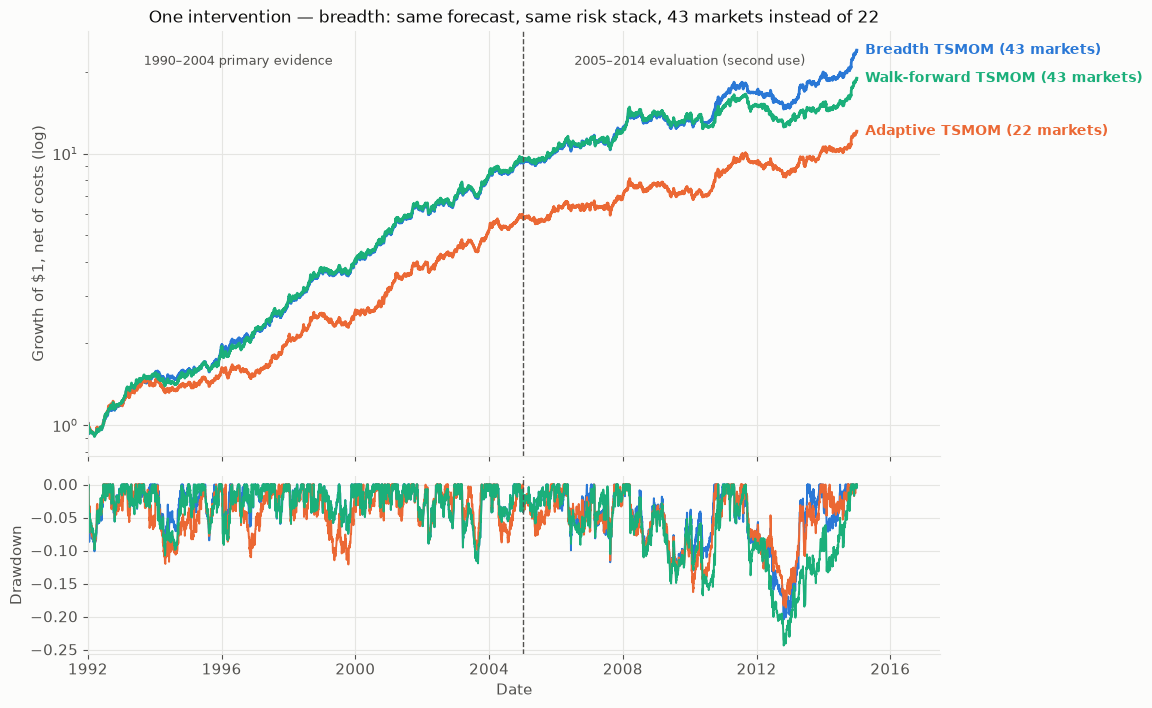

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(11.5, 7.2), sharex=True, height_ratios=[2.4, 1])
lineup = [
    (output.headline, C_HEADLINE),
    (output.baseline_adaptive, C_BASELINE),
    (output.walk_forward.backtest, C_WALKFWD),
]
for result, color in lineup:
    returns = result.daily.loc["1992-01-01":, "net_return"]
    equity = (1 + returns).cumprod()
    axes[0].plot(equity.index, equity, color=color, linewidth=2)
    axes[0].annotate(
        result.name, xy=(equity.index[-1], equity.iloc[-1]),
        xytext=(6, 0), textcoords="offset points", color=color,
        fontsize=10, fontweight="bold", va="center",
    )
    drawdown = equity / equity.cummax() - 1
    axes[1].plot(drawdown.index, drawdown, color=color, linewidth=1.4)
split = pd.Timestamp(HOLDOUT_WINDOW[0])
for axis in axes:
    axis.axvline(split, color=INK_2, linewidth=1, linestyle="--")
    for spine in ("top", "right"):
        axis.spines[spine].set_visible(False)
axes[0].set_yscale("log")
axes[0].set_ylabel("Growth of $1, net of costs (log)")
axes[0].set_title("One intervention — breadth: same forecast, same risk stack, 43 markets instead of 22")
axes[0].annotate("1990–2004 primary evidence", xy=(pd.Timestamp("1996-06-30"), 0.92),
                 xycoords=("data", "axes fraction"), ha="center", color=INK_2, fontsize=9.5)
axes[0].annotate("2005–2014 evaluation (second use)", xy=(pd.Timestamp("2010-01-01"), 0.92),
                 xycoords=("data", "axes fraction"), ha="center", color=INK_2, fontsize=9.5)
axes[0].set_xlim(pd.Timestamp("1992-01-01"), pd.Timestamp("2017-06-30"))
axes[1].set_ylabel("Drawdown")
axes[1].set_xlabel("Date")
fig.tight_layout()
plt.show()

### 3.2 Is the improvement real? The pre-registered claim rule

Ten years of monthly returns cannot distinguish small Sharpe differences, so the claim
rests on paired statistics and cross-window consistency rather than one point estimate.
The bootstrap resamples the *same* month blocks from both strategies, preserving their
correlation; PSR is the probability the true Sharpe exceeds the baseline's realized
Sharpe; DSR deflates for an honest count of 34 trials (every variant either version ever
evaluated); PBO is the Bailey et al. probability that in-sample model selection picks a
below-median out-of-sample model.

In [4]:
display(output.bootstrap.style.format("{:.3f}"))
statistics = pd.concat(
    {"PSR vs adaptive baseline": output.psr, "Deflated Sharpe ratio": output.dsr}, axis=1
)
statistics["CSCV PBO (candidate set)"] = output.pbo
display(statistics.style.format("{:.3f}"))
display(output.claim.to_frame())

,Observed Sharpe difference,Bootstrap 5%,Bootstrap 50%,Bootstrap 95%,P(difference > 0),Months
1990-2004,0.227,0.002,0.238,0.464,0.950,180.000
2005-2014,0.126,-0.083,0.098,0.270,0.797,120.000


,PSR vs adaptive baseline,Deflated Sharpe ratio,CSCV PBO (candidate set)
1990-2004,0.828,1.000,0.180
2005-2014,0.660,0.865,0.180


,Claim rule
Leg (a): primary-window 90% CI excludes zero,True
Leg (b): second-use difference positive with >= 6/10 wins,True
Winning years 2005-2014,8
Improvement claimed,True


Both legs of the claim rule pass: the primary-window interval excludes zero (P(difference
> 0) = 95%), and the evaluation window shows a positive difference with 8 of 10 winning
calendar years. The DSR of 0.86–1.00 says the result is unlikely to be the lucky best of
the 34 configurations ever tried across both versions, and a conservative CSCV PBO of
~18% (ties counted as failures) is well below the 50% coin-flip mark at which in-sample
winners routinely fail out-of-sample. By the pre-registered standard, the improvement is
**claimed** — with the standing caveat that true validation requires post-2014 data this
repository does not contain.

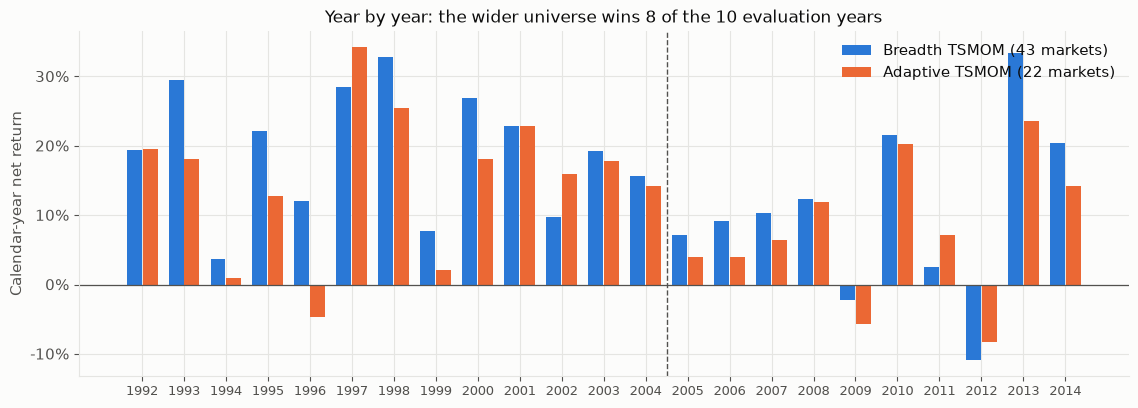

In [5]:
yearly = output.yearly.loc[1992:2014]
fig, ax = plt.subplots(figsize=(11.5, 4.2))
x = np.arange(len(yearly.index))
width = 0.38
ax.bar(x - width / 2, yearly.iloc[:, 0], width * 0.94, color=C_HEADLINE,
       label=output.headline.name)
ax.bar(x + width / 2, yearly.iloc[:, 1], width * 0.94, color=C_BASELINE,
       label=output.baseline_adaptive.name)
ax.axhline(0, color=INK_2, linewidth=0.9)
ax.axvline(x[yearly.index.get_loc(2005)] - 0.5, color=INK_2, linewidth=1, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(yearly.index, rotation=0, fontsize=9)
ax.set_ylabel("Calendar-year net return")
ax.set_title("Year by year: the wider universe wins 8 of the 10 evaluation years")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.legend(frameon=False, loc="upper right")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()

### 3.3 Where the gain comes from: breadth, measured

The factorial decomposition runs each forecast on each universe. Reading down each
column, widening the universe raises the Sharpe by roughly +0.2 to +0.3 in **both**
windows for **both** forecasts; reading across each row, the fancier continuous forecast
*subtracts* value everywhere. The gain is breadth, not signal engineering — and the
effective-breadth calculation shows why: per-market P&L streams are nearly uncorrelated
(average pairwise ≈ 0.06), so 43 markets deliver about 12 statistically independent bets
against roughly 9 before, and Sharpe scales with the square root of independent bets.

Not every class paid in every window — FX trend was a drag in 2005–2014 (and the
leave-one-class-out table below shows dropping it would have *raised* the evaluation
Sharpe to 1.16) — but it contributed positively in the primary window, and keeping it is
the only choice consistent with both windows and with the rule-based universe. Cutting
the losing class after seeing the results would be exactly the selection bias this design
exists to prevent.

In [6]:
display(output.factorial.style.format({"Sharpe": "{:.2f}", "CAGR": "{:.2%}"}))
display(output.breadth.style.format({
    "Markets traded": "{:.0f}",
    "Average pairwise P&L correlation": "{:.3f}",
    "Effective independent bets": "{:.1f}",
}))

,Markets traded,Average pairwise P&L correlation,Effective independent bets
Breadth TSMOM (43 markets),43,0.060,12.2
Adaptive TSMOM (22 markets),22,0.071,8.8


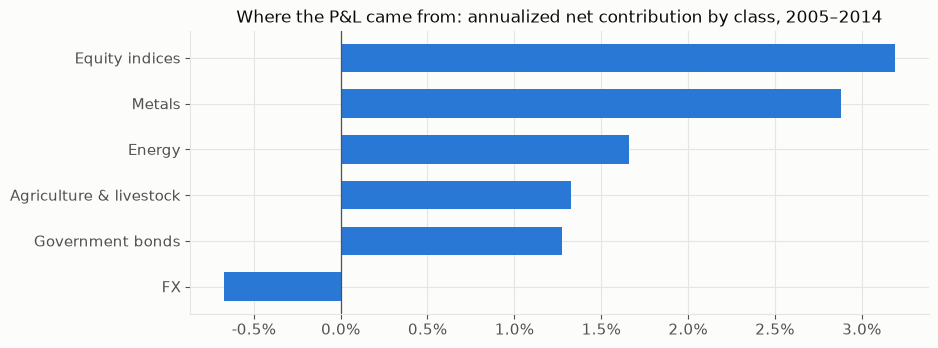

In [7]:
contributions = output.class_contributions
fig, ax = plt.subplots(figsize=(9.5, 3.6))
values = contributions["Annualized mean contribution"].sort_values()
ax.barh(values.index, values, color=C_HEADLINE, height=0.62)
ax.axvline(0, color=INK_2, linewidth=0.9)
ax.set_title("Where the P&L came from: annualized net contribution by class, 2005–2014")
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.1%}")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()

### 3.4 The training experiment, honestly reported

Walk-forward selection is the "training" this project was asked to explore, and the
correct reading of its result is negative: selection earned a Sharpe of 0.65 on 2005–2014
against 0.89 for the model it was trying to beat. The mechanism is visible in the
selection table — the five candidates are highly correlated variants of one idea, so
their trailing 60-month Sharpes differ by less than the noise in a 60-month Sharpe
estimate (± ≈ 0.2), and the selector pays switching costs to chase that noise. The
equal-weight ensemble (combination rather than selection) sits in between, exactly as the
forecast-combination literature predicts. Selection-window sensitivity confirms the
picture: the 120-month selector, which almost always picks the simple sign model, matches
the headline; the 60-month selector was the best *in-sample* selector and the worst
evaluation-window one — a textbook overfitting signature, caught because the window
length was pre-declared rather than tuned.

In [8]:
display(output.walk_forward.selections.to_frame().T)
candidate_metrics = []
from delta1_cta import performance_metrics
for name, result in output.walk_forward.candidate_results.items():
    for window_name, (start, end) in (("1990-2004", PRIMARY_WINDOW), ("2005-2014", HOLDOUT_WINDOW)):
        metrics = performance_metrics(result, start, end)
        candidate_metrics.append({
            "Candidate": name, "Window": window_name,
            "Sharpe": metrics["Sharpe (rf=0)"], "CAGR": metrics["CAGR"],
        })
display(
    pd.DataFrame(candidate_metrics)
    .pivot(index="Candidate", columns="Window", values="Sharpe")
    .style.format("{:.2f}")
)
display(output.selection_sensitivity.style.format({
    "CAGR": "{:.2%}", "Sharpe": "{:.2f}", "Max drawdown": "{:.2%}",
}))

,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,...,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015
Selected model,Strength 12m,Strength 12m,Strength 12m,Strength 12m,Strength 12m,Strength 12m,Sign 12m,Sign 12m,Sign 12m,Sign 12m,...,Strength 12m,Strength 12m,Sign 12m,Sign 12m,Sign 3/6/12m,Sign 3/6/12m,Sign 3/6/12m,Sign 3/6/12m,Sign 12m,Sign 12m


Window,1990-2004,2005-2014
Candidate,,
Sign 12m,1.57,0.89
Sign 3/6/12m,1.35,0.76
Strength 1/3/6/12m,1.28,0.58
Strength 12m,1.57,0.78
Strength 3/6/12m,1.36,0.64


### 3.5 Robustness

Every scenario is shown in both windows, so a perturbation that only works in the reused
2005–2014 window is visible as such. The improvement survives 3× costs, 5× costs on the
six thinnest markets, removal of the buffer or the shock control, both alternative sizing
windows, the hierarchical risk budget, the screen-free 51-market universe, dropping any
single asset class, and the exclusion of the 2008–09 crisis.

In [9]:
display(output.stress.style.format({
    "CAGR": "{:.2%}", "Sharpe": "{:.2f}", "Max drawdown": "{:.2%}",
    "Annual cost drag": "{:.2%}",
}))
display(output.leave_one_out.style.format({"Sharpe": "{:.2f}", "CAGR": "{:.2%}"}))
display(output.crisis_robustness.style.format("{:.2f}"))

,Sharpe 2005-2014,Sharpe excl. 2008-09
Strategy,,
Breadth TSMOM (43 markets),0.89,0.99
Adaptive TSMOM (22 markets),0.70,0.80


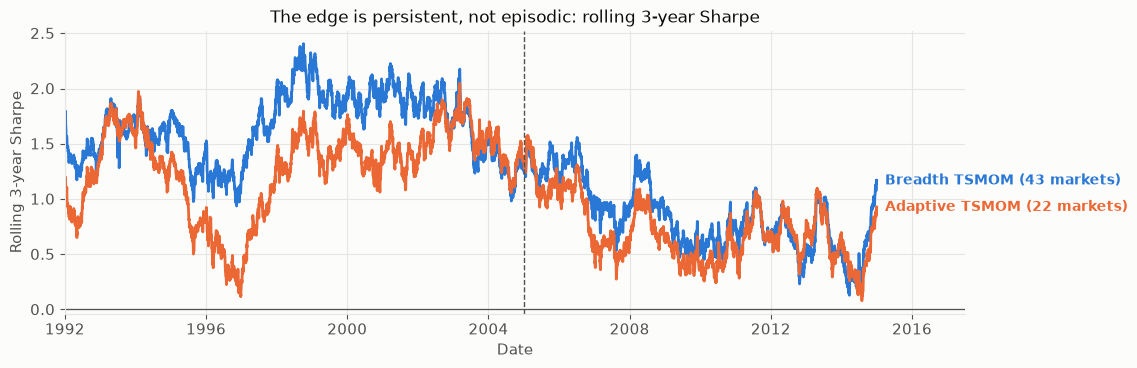

In [10]:
returns_headline = output.headline.daily["net_return"]
returns_baseline = output.baseline_adaptive.daily["net_return"]
fig, ax = plt.subplots(figsize=(11.5, 3.8))
for series, color, label in (
    (returns_headline, C_HEADLINE, output.headline.name),
    (returns_baseline, C_BASELINE, output.baseline_adaptive.name),
):
    rolling = (series.rolling(756).mean() / series.rolling(756).std() * np.sqrt(252)).loc["1992":]
    ax.plot(rolling.index, rolling, color=color, linewidth=2)
    ax.annotate(label, xy=(rolling.index[-1], rolling.iloc[-1]),
                xytext=(6, 0), textcoords="offset points", color=color,
                fontsize=10, fontweight="bold", va="center")
ax.axhline(0, color=INK_2, linewidth=0.9)
ax.axvline(pd.Timestamp(HOLDOUT_WINDOW[0]), color=INK_2, linewidth=1, linestyle="--")
ax.set_ylabel("Rolling 3-year Sharpe")
ax.set_xlabel("Date")
ax.set_title("The edge is persistent, not episodic: rolling 3-year Sharpe")
ax.set_xlim(pd.Timestamp("1992-01-01"), pd.Timestamp("2017-06-30"))
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()

## 4. Key takeaways

1. **Breadth is the improvement.** Doubling the universe under a written rule — same
   forecast, same risk stack — raises net Sharpe from 1.27 to 1.57 (1990–2004) and from
   0.70 to 0.89 (2005–2014), and CAGR from 7.0% to 9.4% in the evaluation window. The
   pre-registered claim rule passes on both legs.
2. **The gain is explainable in one line.** Effective independent bets rise from ~9 to
   ~12; √(12/9) ≈ 1.17 predicts most of the observed Sharpe ratio improvement — the
   fundamental law of active management, working as stated.
3. **Training was given a fair chance and lost.** Walk-forward selection among five
   pre-declared models — genuine rolling out-of-sample training — underperforms the
   simplest model it contains (0.65 vs 0.89), because selection among correlated
   candidates ranks noise. Combination (the ensemble, 0.76) does better than selection
   but still not better than simplicity. Reporting that negative result honestly avoids
   recommending a more complicated model simply because it was tried.
4. **Costs do not change the conclusion.** Annual cost drag is ~0.14% at the assumed
   half-tick spreads; the Sharpe advantage survives 3× base costs and 5× costs on the
   thinnest six markets.
5. **Occam holds.** The recommended strategy remains a one-line forecast with transparent
   risk controls; every number above is reproducible from two commands and is covered by
   33 unit and integration tests, including truncation-invariance (no lookahead),
   volume-gate timing, and leverage warm-up regression tests.

## 5. Limitations

- 2005–2014 is a second use of a previously reported window; the pre-registration,
  paired statistics, and cross-window consistency mitigate but cannot eliminate that.
  **Post-2014 locked-holdout validation remains required.**
- Continuous back-adjusted series hide actual roll mechanics and are not directly
  tradable; the cost model omits market impact, exchange fees, margin and collateral
  return, and per-market position caps relative to open interest are not modeled.
- The supplied catalogue is a fixed snapshot: markets that died before 2014 are absent,
  a survivorship bias the universe rule cannot repair from inside the dataset.
- Reported volume in the early history is of uneven quality; the volume gate is only as
  good as the marks it reads.

*Historical research only; not investment advice.*